# =====================================================
# NOTEBOOK INFORMATION
# =====================================================

# Privacy-Preserving Federated Network Intrusion Detection System

## Notebook 05 - Baseline Model Comparison

### Objectives

- Load the feature-engineered training and testing datasets
- Scale features without data leakage
- Train baseline machine learning models
- Compare model performance
- Generate evaluation metrics and visualizations
- Identify the strongest centralized baseline

In [9]:
# =====================================================
# IMPORT LIBRARIES
# =====================================================

from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [10]:
# =====================================================
# PROJECT CONFIGURATION
# =====================================================

PROJECT_ROOT = Path.cwd().parent

PROCESSED_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

RESULTS_PATH = PROJECT_ROOT / "results"
METRICS_PATH = RESULTS_PATH / "metrics"
FIGURES_PATH = RESULTS_PATH / "figures"
MODELS_PATH = RESULTS_PATH / "models"

for path in [
    METRICS_PATH,
    FIGURES_PATH,
    MODELS_PATH
]:
    path.mkdir(
        parents=True,
        exist_ok=True
    )

TRAIN_PATH = (
    PROCESSED_DATA_PATH
    / "CICIDS2017_train.csv"
)

TEST_PATH = (
    PROCESSED_DATA_PATH
    / "CICIDS2017_test.csv"
)

print("Training file:", TRAIN_PATH)
print("Testing file :", TEST_PATH)

Training file: c:\MyFiles\Project\Privacy-Preserving-Federated-NIDS\data\processed\CICIDS2017_train.csv
Testing file : c:\MyFiles\Project\Privacy-Preserving-Federated-NIDS\data\processed\CICIDS2017_test.csv


In [11]:
# =====================================================
# LOAD TRAINING AND TESTING DATA
# =====================================================

train_df = pd.read_csv(
    TRAIN_PATH
)

test_df = pd.read_csv(
    TEST_PATH
)

print(
    f"Training shape: {train_df.shape}"
)

print(
    f"Testing shape : {test_df.shape}"
)

Training shape: (2016638, 48)
Testing shape : (504160, 48)


In [12]:
# =====================================================
# SEPARATE FEATURES AND TARGET
# =====================================================

X_train = train_df.drop(
    columns=["Label"]
)

y_train = train_df["Label"]

X_test = test_df.drop(
    columns=["Label"]
)

y_test = test_df["Label"]

print(
    f"Training features: {X_train.shape}"
)

print(
    f"Testing features : {X_test.shape}"
)

print(
    f"Number of classes: {y_train.nunique()}"
)

Training features: (2016638, 47)
Testing features : (504160, 47)
Number of classes: 15


In [13]:
# =====================================================
# ENCODE TARGET LABELS
# =====================================================

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(
    y_train
)

y_test_encoded = label_encoder.transform(
    y_test
)

print("Classes:")

for number, label in enumerate(
    label_encoder.classes_
):
    print(
        f"{number}: {label}"
    )

Classes:
0: BENIGN
1: Bot
2: DDoS
3: DoS GoldenEye
4: DoS Hulk
5: DoS Slowhttptest
6: DoS slowloris
7: FTP-Patator
8: Heartbleed
9: Infiltration
10: PortScan
11: SSH-Patator
12: Web Attack � Brute Force
13: Web Attack � Sql Injection
14: Web Attack � XSS


In [14]:
# =====================================================
# FEATURE SCALING
# =====================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("Feature scaling completed.")

print(
    "Training shape:",
    X_train_scaled.shape
)

print(
    "Testing shape :",
    X_test_scaled.shape
)

Feature scaling completed.
Training shape: (2016638, 47)
Testing shape : (504160, 47)


In [15]:
# =====================================================
# DEFINE BASELINE MODELS
# =====================================================

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        eval_metric="mlogloss"
    )
}

print("Models defined successfully.")

for model_name in models:
    print("-", model_name)

Models defined successfully.
- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost


In [16]:
# =====================================================
# TRAIN BASELINE MODELS
# =====================================================

results = []
trained_models = {}
predictions_dict = {}

for name, model in models.items():

    print("\n" + "=" * 60)
    print(f"Training: {name}")
    print("=" * 60)

    model.fit(
        X_train_scaled,
        y_train_encoded
    )

    predictions = model.predict(
        X_test_scaled
    )

    accuracy = accuracy_score(
        y_test_encoded,
        predictions
    )

    precision = precision_score(
        y_test_encoded,
        predictions,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test_encoded,
        predictions,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test_encoded,
        predictions,
        average="weighted",
        zero_division=0
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    trained_models[name] = model
    predictions_dict[name] = predictions

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")


Training: Logistic Regression
Accuracy : 0.8335
Precision: 0.9648
Recall   : 0.8335
F1 Score : 0.8864

Training: Decision Tree
Accuracy : 0.9983
Precision: 0.9983
Recall   : 0.9983
F1 Score : 0.9983

Training: Random Forest
Accuracy : 0.9981
Precision: 0.9985
Recall   : 0.9981
F1 Score : 0.9983

Training: XGBoost
Accuracy : 0.9989
Precision: 0.9988
Recall   : 0.9989
F1 Score : 0.9988


In [17]:
# =====================================================
# MODEL COMPARISON
# =====================================================

results_df = pd.DataFrame(
    results
)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(
    drop=True
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost,0.998854,0.998843,0.998854,0.998790
1,Decision Tree,0.998298,0.998289,0.998298,0.998292
2,Random Forest,0.998139,0.998510,0.998139,0.998262
3,Logistic Regression,0.833521,0.964807,0.833521,0.886408


In [18]:
# =====================================================
# FORMAT PERFORMANCE RESULTS
# =====================================================

display_df = results_df.copy()

for column in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]:
    display_df[column] = (
        display_df[column] * 100
    ).round(2)

display_df

,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost,99.89,99.88,99.89,99.88
1,Decision Tree,99.83,99.83,99.83,99.83
2,Random Forest,99.81,99.85,99.81,99.83
3,Logistic Regression,83.35,96.48,83.35,88.64


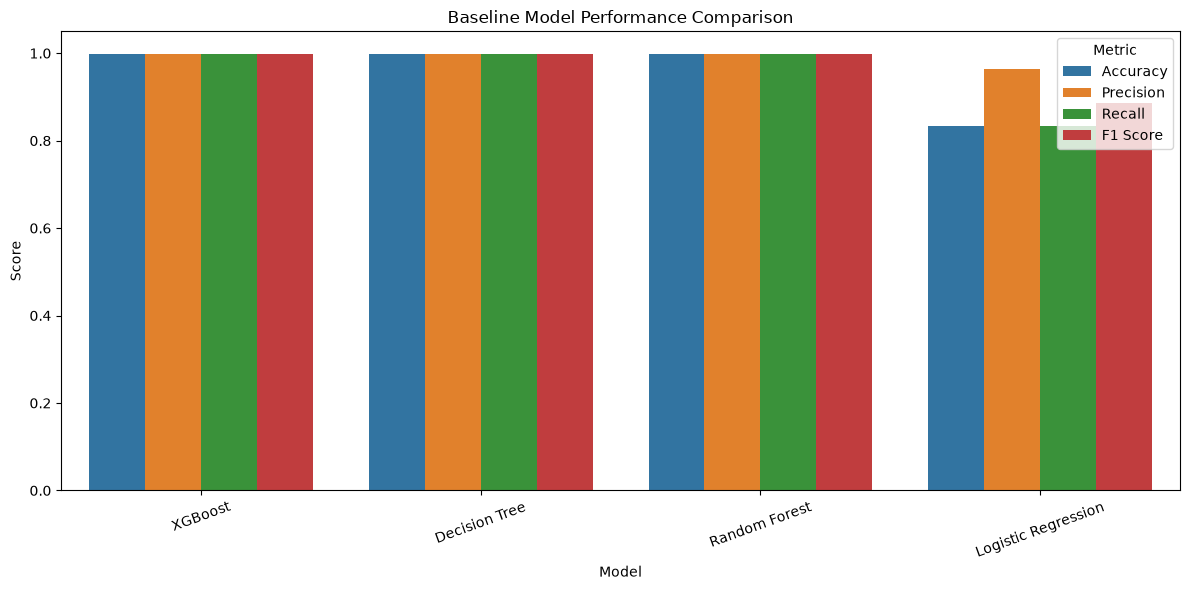

In [19]:
# =====================================================
# MODEL PERFORMANCE VISUALIZATION
# =====================================================

plot_df = results_df.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=plot_df,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.ylim(0, 1.05)

plt.title(
    "Baseline Model Performance Comparison"
)

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "baseline_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
# =====================================================
# SELECT BEST CENTRALIZED MODEL
# =====================================================

best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[
    best_model_name
]

print(
    f"Best centralized model: "
    f"{best_model_name}"
)

print(
    f"F1 Score: "
    f"{results_df.iloc[0]['F1 Score']:.4f}"
)


Best centralized model: XGBoost
F1 Score: 0.9988


In [21]:
# =====================================================
# CLASSIFICATION REPORT
# =====================================================

best_predictions = predictions_dict[
    best_model_name
]

print(
    f"Classification Report - "
    f"{best_model_name}"
)

print()

print(
    classification_report(
        y_test_encoded,
        best_predictions,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)


Classification Report - XGBoost

                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    419012
                       Bot       0.92      0.72      0.81       390
                      DDoS       1.00      1.00      1.00     25603
             DoS GoldenEye       1.00      0.99      0.99      2057
                  DoS Hulk       1.00      1.00      1.00     34569
          DoS Slowhttptest       0.99      1.00      0.99      1046
             DoS slowloris       1.00      0.99      0.99      1077
               FTP-Patator       1.00      1.00      1.00      1186
                Heartbleed       1.00      0.50      0.67         2
              Infiltration       1.00      0.86      0.92         7
                  PortScan       0.99      1.00      0.99     18139
               SSH-Patator       1.00      1.00      1.00       644
  Web Attack � Brute Force       0.73      0.96      0.83       294
Web Attack � S

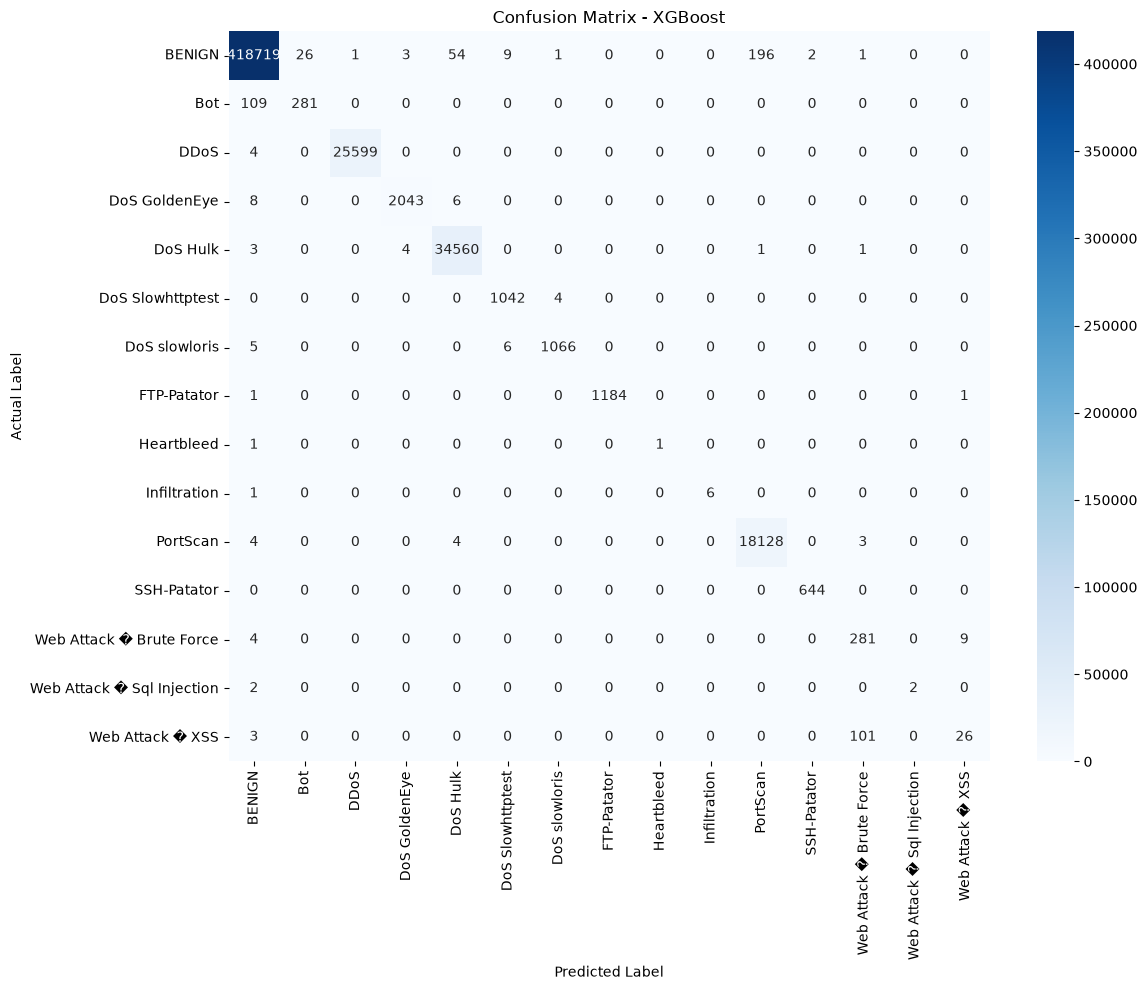

In [22]:
# =====================================================
# CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(
    y_test_encoded,
    best_predictions
)

plt.figure(
    figsize=(12, 10)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "Actual Label"
)

plt.xticks(
    rotation=90
)

plt.yticks(
    rotation=0
)

plt.tight_layout()

plt.savefig(
    FIGURES_PATH
    / "baseline_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
# =====================================================
# SAVE MODEL COMPARISON RESULTS
# =====================================================

results_df.to_csv(
    METRICS_PATH
    / "baseline_model_comparison.csv",
    index=False
)

print(
    "Baseline results saved successfully."
)

Baseline results saved successfully.


In [24]:
# =====================================================
# SAVE LABEL ENCODER MAPPING
# =====================================================

label_mapping = pd.DataFrame({
    "Encoded_Label": range(
        len(label_encoder.classes_)
    ),
    "Original_Label":
        label_encoder.classes_
})

label_mapping.to_csv(
    METRICS_PATH
    / "baseline_label_mapping.csv",
    index=False
)

label_mapping

,Encoded_Label,Original_Label
0,0,BENIGN
1,1,Bot
2,2,DDoS
3,3,DoS GoldenEye
4,4,DoS Hulk
5,5,DoS Slowhttptest
6,6,DoS slowloris
7,7,FTP-Patator
8,8,Heartbleed
9,9,Infiltration
